### Parameters for the exercise

I have chosen to work on the relationship between two datasets centred in <b>Spain</b> in the period between <b>April, 2014</b> and <b>April, 2017</b>: one containing daily information about several weather parameters (solar radiation, rainfall, windspeed, minimum, maximum and average temperatures) and another one containing information about the hourly evolution of electricity prices.

(all links below are to newspaper articles written in Spanish)

# On the impact of weather conditions on energy prices in Spain

Over recent years, energy prices in Spain have been on the rise and this has been the source of much social concern. For example, there have been public demonstrations and legislative initiatives regarding _fuel poverty_, seeking to protect those who cannot afford to keep their homes warm in the winter (this subject appears often in Spanish news, see <a href="http://elpais.com/tag/pobreza_energetica/a">here</a> for a selection of articles in Spanish). The polemics reached great heights when the right-wing central government in Spain took a law that had been passed by the Catalan government to the Constitutional Court, thus effectively favouring big energy companies, some of which are former national monopolies, over those who are socially disfavoured (see <a href="http://www.elperiodico.com/es/noticias/politica/tribunal-constitucional-suspende-parte-ley-catalana-emergencia-social-5170369">here</a>, in Spanish).

Another great point of social concern arrived in January, 2017, when the prices of electricity suddenly sky-rocketed and consumers had to face rises in their power bills of up to 26% (<a href="http://www.elperiodico.com/es/noticias/politica/tribunal-constitucional-suspende-parte-ley-catalana-emergencia-social-5170369">here</a>, in Spanish).

The Spanish prime minister went on record to claim that the sudden price rise was due to a combination of unlucky circumstances, having much to do with the lack of rains and extremely cold temperatures, and that the prices would go down as soon as it would rain. Our purpose here is to put his claim to the test.

## How is a power bill calculated in Spain?

A home (H) will buy its power supply from a distributing company (A) that, in its turn, buys electricity from a producing company (B). The price at which company A buys electricity from company B is updated hourly and depends on two things:
1. How cheap it might be to produce electricity at that given time.
2. The demand for electricity supply at that given time.

This price is what we will call <b>production cost</b>.

Next, company A sells electricity to H, at a price which is computed by adding a <b>toll</b> to the production cost. This toll takes account of the costs of transporting the electricy from the power station to its final destination H. When computed this way, the final price of electricity is called _Precio Voluntario para el Pequeño Consumidor_ and we will refer to it by the initials __PVPC__. One is also given the choice to ignore the production cost and be charged a flat rate per kWh, but it is estimated that most consumers in Spain choose to pay on the PVPC scheme (13.9 million homes vs. 13 million homes, as of February, 2016; details <a href="http://www.expansion.com/empresas/energia/2016/02/07/56b71fe0e2704ed9798b457c.html">here</a>).

### A dataset containing information about the evolution of prices?

We have launched a script that queries <a href="https://www.esios.ree.es/es/descargas?date_type=datos&start_date=01-01-2007&end_date=23-05-2017">this website</a>, owned by __Red Eléctrica Española__; we have managed to obtain a collection of excel spreadsheets (70 MB) containing the hourly prices for the __production cost__ and the __PVPC__ in the period starting on April 1st, 2016 (the date on which bills started to be computed according to the PVPC scheme) and finishing yesterday. The file `pcpv.csv` contains a summary of such data, which we have used henceforth.

## Our hypotheses about the impact of weather

Apparently (cf. <a href="http://www.lavanguardia.com/economia/20170130/413843146142/electricidad-luz-enero-precio.html">here</a>), the sudden rise in prices in January 2016 was due to a _perfect storm_: lack of rainfall, wind and sunshine, together with very cold temperatures and the fact that France had stopped many of its nuclear powerplants for safety reasons and had come to Spain to buy electricity, therefore increasing the demands.

Renewable sources of energy depend on having appropriate weather conditions; the presence of such conditions could lower energy prices. It is also clear that extreme temperatures will increase the demand for energy (air conditioning in the summer, heating in the winter) and, therefore, they should make prices rise.

As far as weather is concerned, we are interested in verifying the following hypotheses:
1. Rainfall can enhance hydroelectric energy production and, hence, is related to price drops.
2. The presence of strong wind allows for the production of eolic energy and is related to price drops.
3. Solar radiation affects the production of solar energy and is related to price drops.
4. Extreme cold and heat increase the demand for energy and therefore are tied to price rises.

### A dataset containing weather information

The Spanish national meteorology agency (AEMET) have an open data initiative <a href="https://opendata.aemet.es/centrodedescargas/inicio">here</a> (beware; as is often the case with websites related to the Spanish government, their SSL is broken). In particular, we have written a script that uses python's `requests` library in order to query the REST API on this website. In this way, we have obtained a dataset (38 MB) containing daily observations of minimum, maximum and average temperatures; rainfall, solar radiation and windspeed of all weather stations in Spain for the period starting on April 1st, 2014, and ending April 30th, 2017. A summary of this information, obtained by computing daily averages over all weather stations, is available in the file `meteo-summary.csv`.

For the sake of commodity, we have merged both of the summarized datasets and it is possible to load all the data for our experiments on a single dataframe. The data is in the file `combined-data.csv`.

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
# import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
# %matplotlib notebook

In [3]:
csv_file = './data/combined-data.csv'
df = pd.read_csv(csv_file)

# Convert dates to datetime
df.date = pd.to_datetime(df.date)

### Idea

Rainfall on a given day should not be related to the production of electricity on that date, since hydroelectric powerplants take water from reservoirs. We will try to verify whether big accumulations of rainfall in the previous week or month have any impact.

We will count accumulated rainfall during the previous week/month and add it as a variable.

In [8]:
def count_rainfall_prev_week(date):
    df_prev_week = df[(date - dt.timedelta(days=7) <= df.date) & (df.date <= date)]
    return df_prev_week.rainfall_mm.sum()

In [9]:
def count_rainfall_prev_month(date):
    df_prev_week = df[(date - dt.timedelta(days=30) <= df.date) & (df.date <= date)]
    return df_prev_week.rainfall_mm.sum()

In [10]:
def count_rainfall_prev_three_months(date):
    df_prev_week = df[(date - dt.timedelta(days=90) <= df.date) & (df.date <= date)]
    return df_prev_week.rainfall_mm.sum()

In [11]:
df['rainfall_prev_week_mm'] = df['date'].apply(count_rainfall_prev_week)
df['rainfall_prev_month_mm'] = df['date'].apply(count_rainfall_prev_month)
df['rainfall_prev_three_months_mm'] = df['date'].apply(count_rainfall_prev_three_months)

In [12]:
df

,date,rainfall_mm,sunshine_MJ_daym2,tmax_C,tmed_C,tmin_C,windspeed_m_s,pvpc_eur_MWh,prod_cost_eur_MWh,rainfall_prev_week_mm,rainfall_prev_month_mm,rainfall_prev_three_months_mm
0,2014-04-01,4.705306,4.004255,18.084274,13.680645,9.268952,4.288186,64.585172,33.255710,4.705306,4.705306,4.705306
1,2014-04-02,6.861317,1.869565,15.859274,12.467742,9.076210,3.368644,79.112275,46.074043,11.566623,11.566623,11.566623
2,2014-04-03,4.871255,4.052518,14.543651,11.240476,7.938889,3.890678,76.017851,43.501543,16.437878,16.437878,16.437878
3,2014-04-04,1.335484,6.686667,16.576984,12.110714,7.638492,3.982700,53.809466,23.629460,17.773362,17.773362,17.773362
4,2014-04-05,0.295928,6.750365,20.212648,15.401976,10.590514,2.903376,64.498918,33.124877,18.069290,18.069290,18.069290
...,...,...,...,...,...,...,...,...,...,...,...,...
1121,2017-04-26,2.830279,5.327068,16.960800,12.545200,8.135200,3.442735,91.635833,55.900660,7.505453,13.925298,143.406877
1122,2017-04-27,4.769388,6.957778,15.173984,10.604878,6.033333,3.425541,89.400897,53.885493,12.033641,17.626930,143.292515
1123,2017-04-28,4.572245,7.187218,15.517004,10.382186,5.259109,3.587931,92.872691,56.467952,16.603878,22.183046,141.746317
1124,2017-04-29,2.721224,4.903053,17.382041,12.291020,7.179675,3.132618,92.483740,54.778452,19.240518,24.903076,143.550538


### First check: we look up the correlation matrices

In [7]:
df.corr()

,rainfall_mm,sunshine_MJ_daym2,tmax_C,tmed_C,tmin_C,windspeed_m_s,pvpc_eur_MWh,prod_cost_eur_MWh,rainfall_prev_week_mm,rainfall_prev_month_mm,rainfall_prev_three_months_mm
rainfall_mm,1.000000,-0.642393,-0.355662,-0.269032,-0.149729,0.380970,-0.133270,-0.142847,0.491534,0.299892,0.188657
sunshine_MJ_daym2,-0.642393,1.000000,0.752948,0.668456,0.538618,-0.080977,-0.055751,-0.024237,-0.553393,-0.550700,-0.442565
tmax_C,-0.355662,0.752948,1.000000,0.988569,0.941193,-0.117481,0.030212,0.079386,-0.514856,-0.658384,-0.696157
tmed_C,-0.269032,0.668456,0.988569,1.000000,0.981374,-0.073589,0.019443,0.070214,-0.454542,-0.635467,-0.708071
tmin_C,-0.149729,0.538618,0.941193,0.981374,1.000000,-0.015262,0.005122,0.056241,-0.362586,-0.585159,-0.699774
windspeed_m_s,0.380970,-0.080977,-0.117481,-0.073589,-0.015262,1.000000,-0.510265,-0.514273,0.218810,0.006378,0.093295
pvpc_eur_MWh,-0.133270,-0.055751,0.030212,0.019443,0.005122,-0.510265,1.000000,0.995452,-0.125017,-0.095057,-0.046653
prod_cost_eur_MWh,-0.142847,-0.024237,0.079386,0.070214,0.056241,-0.514273,0.995452,1.000000,-0.139769,-0.125102,-0.094790
rainfall_prev_week_mm,0.491534,-0.553393,-0.514856,-0.454542,-0.362586,0.218810,-0.125017,-0.139769,1.000000,0.619728,0.379529
rainfall_prev_month_mm,0.299892,-0.550700,-0.658384,-0.635467,-0.585159,0.006378,-0.095057,-0.125102,0.619728,1.000000,0.696848


Besides the fact that __PVPC__ and __production cost__ are very strongly correlated and several of the weather conditions show strong correlations amongst themselves (big rainfall is related to small solar radiation), there is only one relationship amongst weather and energy cost that sticks out: the impact of windspeed on daily prices.

### What about looking up weekly or monthly aggregates?

Just in case there is a story that daily information fails to see.

In [8]:
df['year'] = df.date.apply(lambda x: x.year)
df['month'] = df.date.apply(lambda x: x.month)
df['week'] = df.date.apply(lambda x: x.isocalendar()[1])

In [10]:
# On some columns we take averages, on some others we sum
cols_agg = {'rainfall_mm':'sum',
            'sunshine_MJ_daym2':'sum',
            'tmax_C':'mean',
            'tmed_C':'mean',
            'tmin_C':'mean',
            'windspeed_m_s':'mean',
            'rainfall_prev_week_mm':'sum',
            'rainfall_prev_month_mm':'sum',
            'rainfall_prev_three_months_mm':'sum',
            'pvpc_eur_MWh':'mean', 
            'prod_cost_eur_MWh':'mean'}

In [13]:
df.groupby(['year', 'week']).agg(cols_agg).corr()

,rainfall_mm,sunshine_MJ_daym2,tmax_C,tmed_C,tmin_C,windspeed_m_s,rainfall_prev_week_mm,rainfall_prev_month_mm,rainfall_prev_three_months_mm,pvpc_eur_MWh,prod_cost_eur_MWh
rainfall_mm,1.000000,-0.619766,-0.456137,-0.381576,-0.281006,0.365283,0.712724,0.444564,0.298149,-0.118200,-0.130108
sunshine_MJ_daym2,-0.619766,1.000000,0.846651,0.800355,0.728161,0.082539,-0.546521,-0.516439,-0.406601,-0.101609,-0.053614
tmax_C,-0.456137,0.846651,1.000000,0.993965,0.969234,-0.063176,-0.501753,-0.612162,-0.643156,0.010720,0.070520
tmed_C,-0.381576,0.800355,0.993965,1.000000,0.990386,-0.046364,-0.440044,-0.582590,-0.644626,0.010476,0.071605
tmin_C,-0.281006,0.728161,0.969234,0.990386,1.000000,-0.024434,-0.354645,-0.535244,-0.635391,0.010019,0.071769
windspeed_m_s,0.365283,0.082539,-0.063176,-0.046364,-0.024434,1.000000,0.246850,-0.004850,0.142646,-0.487586,-0.490497
rainfall_prev_week_mm,0.712724,-0.546521,-0.501753,-0.440044,-0.354645,0.246850,1.000000,0.658688,0.426702,-0.117812,-0.132926
rainfall_prev_month_mm,0.444564,-0.516439,-0.612162,-0.582590,-0.535244,-0.004850,0.658688,1.000000,0.720495,-0.086841,-0.115528
rainfall_prev_three_months_mm,0.298149,-0.406601,-0.643156,-0.644626,-0.635391,0.142646,0.426702,0.720495,1.000000,-0.042975,-0.090333
pvpc_eur_MWh,-0.118200,-0.101609,0.010720,0.010476,0.010019,-0.487586,-0.117812,-0.086841,-0.042975,1.000000,0.996305


In [14]:
df.groupby(['year', 'month']).agg(cols_agg).corr()

,rainfall_mm,sunshine_MJ_daym2,tmax_C,tmed_C,tmin_C,windspeed_m_s,rainfall_prev_week_mm,rainfall_prev_month_mm,rainfall_prev_three_months_mm,pvpc_eur_MWh,prod_cost_eur_MWh
rainfall_mm,1.000000,-0.782559,-0.655802,-0.616055,-0.560952,0.003873,0.950145,0.734091,0.415869,-0.098960,-0.124297
sunshine_MJ_daym2,-0.782559,1.000000,0.890806,0.859640,0.813427,0.220983,-0.810994,-0.739487,-0.552014,-0.124026,-0.075728
tmax_C,-0.655802,0.890806,1.000000,0.997262,0.985964,-0.048987,-0.701502,-0.737485,-0.732126,0.008486,0.069710
tmed_C,-0.616055,0.859640,0.997262,1.000000,0.995610,-0.071977,-0.660972,-0.710929,-0.738853,0.014183,0.076522
tmin_C,-0.560952,0.813427,0.985964,0.995610,1.000000,-0.100535,-0.604521,-0.671751,-0.741577,0.021312,0.084569
windspeed_m_s,0.003873,0.220983,-0.048987,-0.071977,-0.100535,1.000000,-0.003828,-0.004099,0.156444,-0.526580,-0.535396
rainfall_prev_week_mm,0.950145,-0.810994,-0.701502,-0.660972,-0.604521,-0.003828,1.000000,0.869385,0.496820,-0.130341,-0.158302
rainfall_prev_month_mm,0.734091,-0.739487,-0.737485,-0.710929,-0.671751,-0.004099,0.869385,1.000000,0.725178,-0.100228,-0.139424
rainfall_prev_three_months_mm,0.415869,-0.552014,-0.732126,-0.738853,-0.741577,0.156444,0.496820,0.725178,1.000000,-0.041881,-0.100088
pvpc_eur_MWh,-0.098960,-0.124026,0.008486,0.014183,0.021312,-0.526580,-0.130341,-0.100228,-0.041881,1.000000,0.996366


In either case, weekly or monthly, we get similar results.

## Another idea

It seems that on average weather does not impact much on prices. However, let us check whether extreme weather does have an impact on prices. 

In order to do this, we will separate our daily data into extreme weather (below quantile .15 or above quantile .85) and regular weather and perform a t-test in order to test the null hypothesis that both samples are the same.

We will also take the chance to take a scatter plot of this data by distinguishing both sets of points.

In [15]:
def perform_t_test_and_plot(weather_col, high=True):
    # We choose quartile accordingly
    if high:
        qtile = .85
    else: 
        qtile = .15
    
    threshold = df[weather_col].quantile(q=qtile)
    
    if high:
        extreme = df[df[weather_col] >= threshold]
        regular = df[df[weather_col] < threshold]
    else:
        extreme = df[df[weather_col] <= threshold]
        regular = df[df[weather_col] > threshold]
    
    print('Looking up extreme conditions for {}'.format(weather_col))
    print('Extreme subset: Mean = {}\nRegular subset: Mean = {}'.format(extreme.pvpc_eur_MWh.mean(), regular.pvpc_eur_MWh.mean()))
    print('{}'.format(ttest_ind(extreme.pvpc_eur_MWh, regular.pvpc_eur_MWh)))
    
    plt.figure()
    if high:
        plt.plot_date(extreme.date, extreme.pvpc_eur_MWh, fmt='.', label='High {} days'.format(weather_col))
    else:
        plt.plot_date(extreme.date, extreme.pvpc_eur_MWh, fmt='.', label='Low {} days'.format(weather_col))
    plt.plot_date(regular.date, regular.pvpc_eur_MWh, fmt='.', alpha=.4, label='Regular days' )
    plt.title('Average PVPC (€/MWh)')
    plt.legend()
    
    ax = plt.gca()
    x = ax.xaxis

    # rotate the tick labels for the x axis
    for item in x.get_ticklabels():
        item.set_rotation(45)

    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    return
    

Looking up extreme conditions for tmax_C
Extreme subset: Mean = 94.4112374254438
Regular subset: Mean = 91.8709101050695
Ttest_indResult(statistic=2.079615991411079, pvalue=0.037786995823648861)


<IPython.core.display.Javascript object>


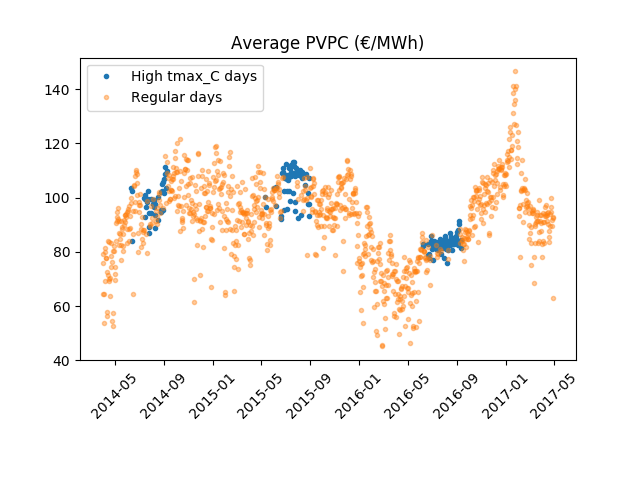

In [16]:
perform_t_test_and_plot('tmax_C', high=True)

Looking up extreme conditions for tmin_C
Extreme subset: Mean = 96.1888371814004
Regular subset: Mean = 91.55699750448768
Ttest_indResult(statistic=3.8088852502767052, pvalue=0.0001471464325702782)


<IPython.core.display.Javascript object>


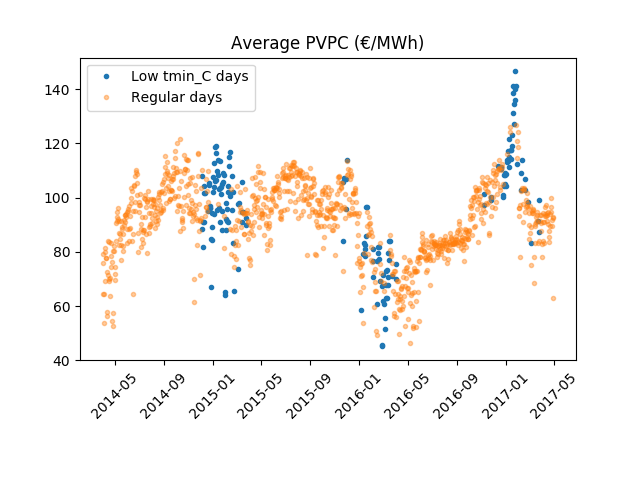

In [17]:
perform_t_test_and_plot('tmin_C', high=False)

Looking up extreme conditions for rainfall_mm
Extreme subset: Mean = 88.6825649269861
Regular subset: Mean = 92.88255655464026
Ttest_indResult(statistic=-3.4498094137177135, pvalue=0.0005817893482834794)


<IPython.core.display.Javascript object>


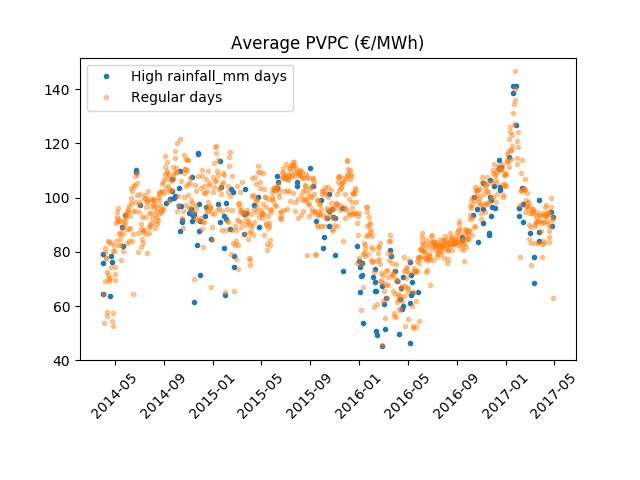

In [18]:
perform_t_test_and_plot('rainfall_mm', high=True)

Looking up extreme conditions for rainfall_prev_week_mm
Extreme subset: Mean = 96.85098638583439
Regular subset: Mean = 91.44006624477058
Ttest_indResult(statistic=4.4600533328043825, pvalue=9.0159260131448085e-06)


<IPython.core.display.Javascript object>


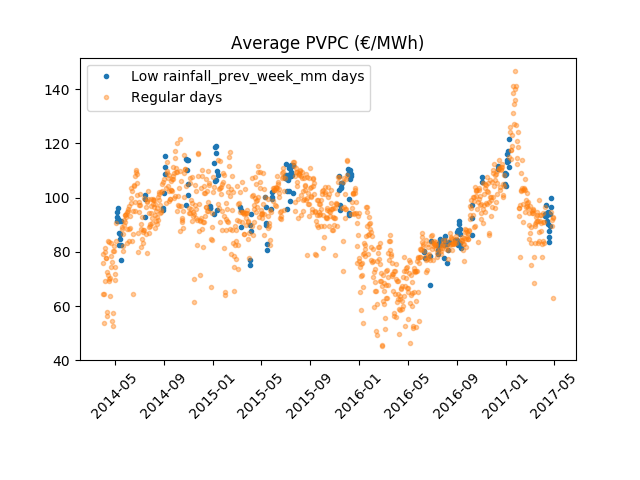

In [19]:
perform_t_test_and_plot('rainfall_prev_week_mm', high=False)

Looking up extreme conditions for rainfall_prev_month_mm
Extreme subset: Mean = 91.57318462426036
Regular subset: Mean = 92.37209184320939
Ttest_indResult(statistic=-0.65288732532905247, pvalue=0.51396243258679142)


<IPython.core.display.Javascript object>


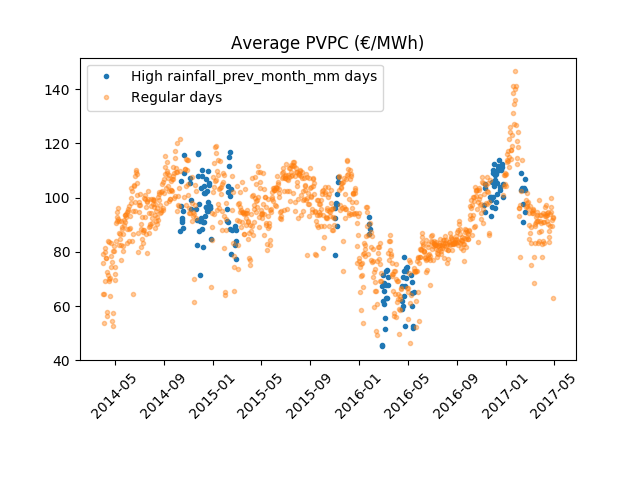

In [20]:
perform_t_test_and_plot('rainfall_prev_month_mm', high=True)

Looking up extreme conditions for sunshine_MJ_daym2
Extreme subset: Mean = 91.54534053293143
Regular subset: Mean = 92.37700892934788
Ttest_indResult(statistic=-0.67967138063748478, pvalue=0.49685250796634484)


<IPython.core.display.Javascript object>


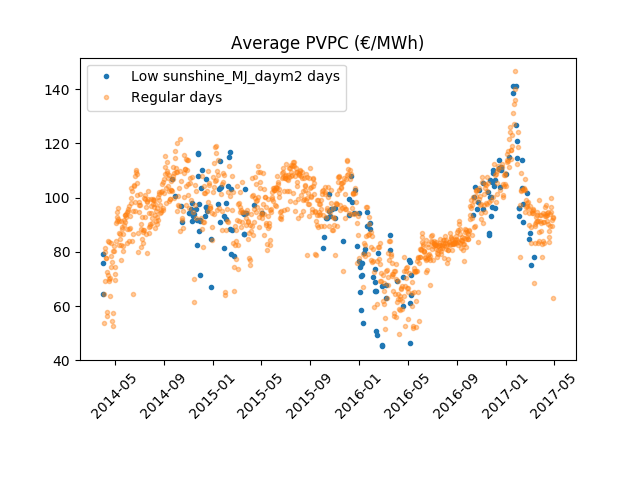

In [21]:
perform_t_test_and_plot('sunshine_MJ_daym2', high=False)

Looking up extreme conditions for windspeed_m_s
Extreme subset: Mean = 79.88901538487822
Regular subset: Mean = 94.4354404340721
Ttest_indResult(statistic=-12.711024789309771, pvalue=1.104137085409237e-34)


<IPython.core.display.Javascript object>


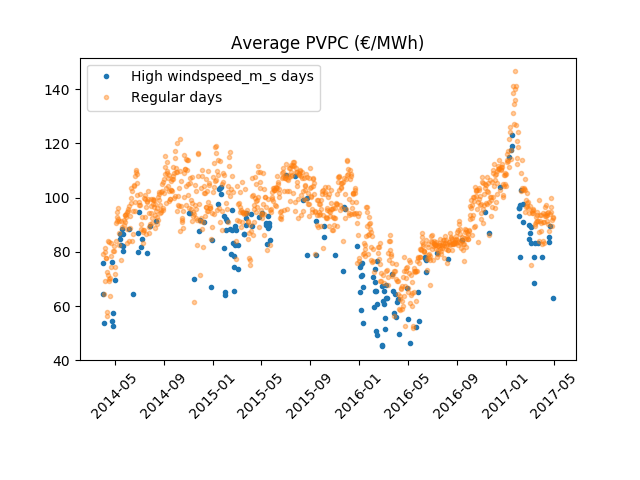

In [22]:
perform_t_test_and_plot('windspeed_m_s', high=True)

# Conclusions

It seems that wind is the one weather condition that could be most strongly related to electricity prices. This is suggested both by the correlation and the t-test results. We could ask ourselves up to which extent would a linear regression predictor relating windspeed to PVPC be accurate.

Extreme cold also is related to increases in energy prices, while it seems that extreme heat does not affect the price so much. The extreme cold in January 2016 that lead to a massive increase in energy prices is perfectly visible on the graphic.

Finally, it seems that heavy rains during the previous week also can imply cheaper energy.